In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.manifold import TSNE

In [2]:
base_path = "/kaggle/input/datasets/sameerrahman778/driver-drowsiness-detection"

train_dir = base_path + "/Train"
val_dir   = base_path + "/Val"
test_dir  = base_path + "/Test"

print("Train Path:", train_dir)
print("Validation Path:", val_dir)
print("Test Path:", test_dir)

Train Path: /kaggle/input/datasets/sameerrahman778/driver-drowsiness-detection/Train
Validation Path: /kaggle/input/datasets/sameerrahman778/driver-drowsiness-detection/Val
Test Path: /kaggle/input/datasets/sameerrahman778/driver-drowsiness-detection/Test


In [3]:
temp_data = datasets.ImageFolder(train_dir)

print("Classes:")
print(temp_data.classes)

print("\nTotal Training Images:")
print(len(temp_data))

Classes:
['Closed_Eyes', 'No_yawn', 'Open_Eyes', 'Yawn']

Total Training Images:
8548


In [4]:
class_names = [
    'Closed_Eyes',
    'No_yawn',
    'Open_Eyes',
    'Yawn'
]

print(class_names)

['Closed_Eyes', 'No_yawn', 'Open_Eyes', 'Yawn']


In [5]:
transform_train = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomRotation(15),

    transforms.RandomHorizontalFlip(),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.3
    ),

    transforms.GaussianBlur(3),

    transforms.ToTensor()
])

transform_test = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()
])

In [6]:
train_data = datasets.ImageFolder(
    train_dir,
    transform=transform_train
)

val_data = datasets.ImageFolder(
    val_dir,
    transform=transform_test
)

test_data = datasets.ImageFolder(
    test_dir,
    transform=transform_test
)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 268
Validation batches: 49
Test batches: 46


In [7]:
class EarlyStopping:

    def __init__(self, patience=4):

        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.stop = False

    def __call__(self, val_loss):

        if self.best_loss is None:

            self.best_loss = val_loss

        elif val_loss > self.best_loss:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True

        else:

            self.best_loss = val_loss
            self.counter = 0

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cuda


In [9]:
def get_resnet():

    model = models.resnet18(pretrained=True)

    model.fc = nn.Linear(
        model.fc.in_features,
        4
    )

    return model

In [10]:
def get_mobilenet():

    model = models.mobilenet_v2(pretrained=True)

    model.classifier[1] = nn.Linear(
        model.last_channel,
        4
    )

    return model

In [11]:
def get_effnet():

    model = models.efficientnet_b0(pretrained=True)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        4
    )

    return model

In [12]:
def train(model, name, epochs=25):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    early_stop = EarlyStopping(
        patience=4
    )

    print(f"\n========== Training {name} ==========")

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------

        model.train()

        train_loss = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            out = model(x)

            loss = criterion(out, y)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        # ---------------- VALIDATION ----------------

        model.eval()

        val_loss = 0

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(device)
                y = y.to(device)

                out = model(x)

                loss = criterion(out, y)

                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        print(
            f"{name} | Epoch {epoch+1} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val Loss: {val_loss:.4f}"
        )

        early_stop(val_loss)

        if early_stop.stop:

            print(f"\nEarly stopping triggered for {name}")

            break

    return model

In [13]:
resnet = get_resnet()

mobilenet = get_mobilenet()

effnet = get_effnet()

resnet = train(
    resnet,
    "ResNet18"
)

mobilenet = train(
    mobilenet,
    "MobileNetV2"
)

effnet = train(
    effnet,
    "EfficientNetB0"
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 204MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 169MB/s]



========== Training ResNet18 ==========
ResNet18 | Epoch 1 | Train Loss: 0.1048 | Val Loss: 0.0314
ResNet18 | Epoch 2 | Train Loss: 0.0433 | Val Loss: 0.0185
ResNet18 | Epoch 3 | Train Loss: 0.0259 | Val Loss: 0.0166
ResNet18 | Epoch 4 | Train Loss: 0.0216 | Val Loss: 0.0088
ResNet18 | Epoch 5 | Train Loss: 0.0276 | Val Loss: 0.0211
ResNet18 | Epoch 6 | Train Loss: 0.0256 | Val Loss: 0.0115
ResNet18 | Epoch 7 | Train Loss: 0.0230 | Val Loss: 0.0103
ResNet18 | Epoch 8 | Train Loss: 0.0171 | Val Loss: 0.0166

Early stopping triggered for ResNet18

========== Training MobileNetV2 ==========
MobileNetV2 | Epoch 1 | Train Loss: 0.1342 | Val Loss: 0.0266
MobileNetV2 | Epoch 2 | Train Loss: 0.0471 | Val Loss: 0.0272
MobileNetV2 | Epoch 3 | Train Loss: 0.0281 | Val Loss: 0.0148
MobileNetV2 | Epoch 4 | Train Loss: 0.0187 | Val Loss: 0.0177
MobileNetV2 | Epoch 5 | Train Loss: 0.0183 | Val Loss: 0.0176
MobileNetV2 | Epoch 6 | Train Loss: 0.0157 | Val Loss: 0.0176
MobileNetV2 | Epoch 7 | Train Lo

In [14]:
def evaluate(model, name):

    model = model.to(device)

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    features = []

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)

            out = model(x)

            prob = torch.softmax(
                out,
                dim=1
            )

            preds = torch.argmax(
                prob,
                dim=1
            )

            y_true.extend(
                y.numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )

            y_prob.extend(
                prob.cpu().numpy()
            )

            features.append(
                out.cpu().numpy()
            )

    # ---------------- ACCURACY ----------------

    accuracy = np.mean(
        np.array(y_true) == np.array(y_pred)
    )

    print(f"\n========== {name} ==========")

    print(f"Accuracy: {accuracy:.4f}")

    # ---------------- CLASSIFICATION REPORT ----------------

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    # ---------------- CONFUSION MATRIX ----------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.title(
        f"{name} Confusion Matrix"
    )

    plt.show()

    # ---------------- ROC AUC ----------------

    roc_auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class='ovr'
    )

    print("ROC-AUC:", roc_auc)

    # ---------------- t-SNE ----------------

    features = np.concatenate(features)

    tsne = TSNE(
        n_components=2,
        random_state=42
    )

    reduced = tsne.fit_transform(
        features
    )

    plt.figure(figsize=(7,6))

    plt.scatter(
        reduced[:,0],
        reduced[:,1],
        c=y_true
    )

    plt.title(
        f"t-SNE Visualization - {name}"
    )

    plt.show()

    return accuracy


========== ResNet18 ==========
Accuracy: 0.9570
              precision    recall  f1-score   support

 Closed_Eyes       1.00      0.86      0.93       361
     No_yawn       0.98      0.99      0.99       469
   Open_Eyes       0.79      1.00      0.89       186
        Yawn       0.99      0.98      0.98       448

    accuracy                           0.96      1464
   macro avg       0.94      0.96      0.95      1464
weighted avg       0.96      0.96      0.96      1464



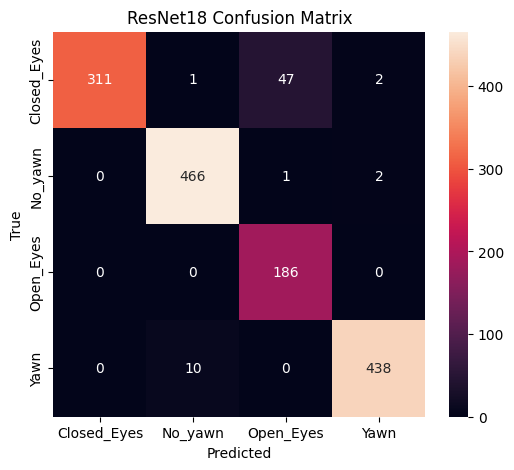

ROC-AUC: 0.9986314307351689


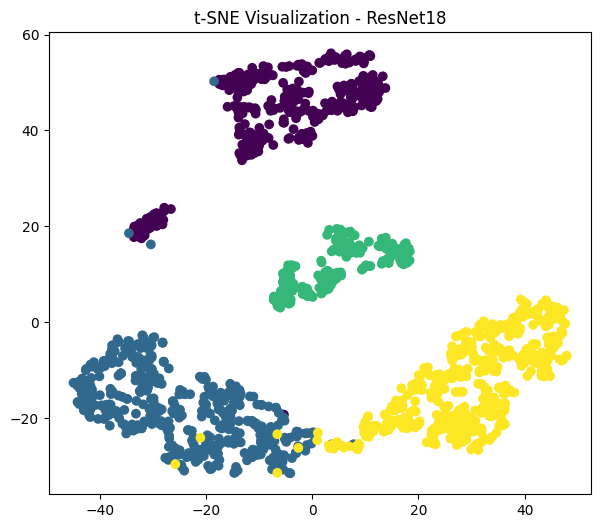


========== MobileNetV2 ==========
Accuracy: 0.9665
              precision    recall  f1-score   support

 Closed_Eyes       1.00      0.92      0.96       361
     No_yawn       0.98      0.98      0.98       469
   Open_Eyes       0.86      1.00      0.93       186
        Yawn       0.98      0.98      0.98       448

    accuracy                           0.97      1464
   macro avg       0.95      0.97      0.96      1464
weighted avg       0.97      0.97      0.97      1464



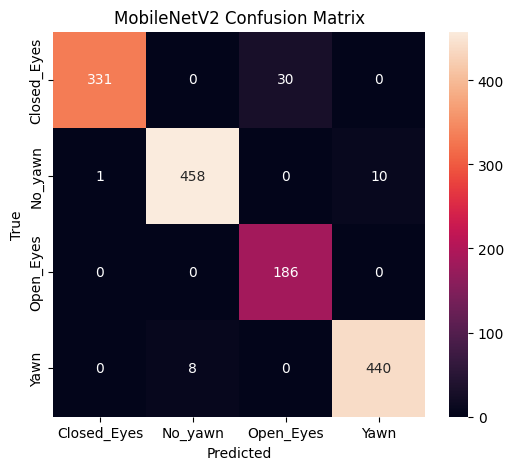

ROC-AUC: 0.9978639366064316


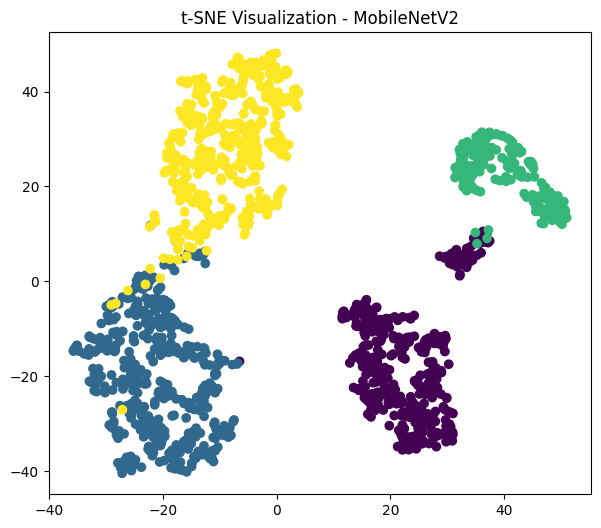


========== EfficientNetB0 ==========
Accuracy: 0.9645
              precision    recall  f1-score   support

 Closed_Eyes       1.00      0.90      0.95       361
     No_yawn       0.97      1.00      0.98       469
   Open_Eyes       0.85      1.00      0.92       186
        Yawn       1.00      0.97      0.98       448

    accuracy                           0.96      1464
   macro avg       0.95      0.97      0.96      1464
weighted avg       0.97      0.96      0.96      1464



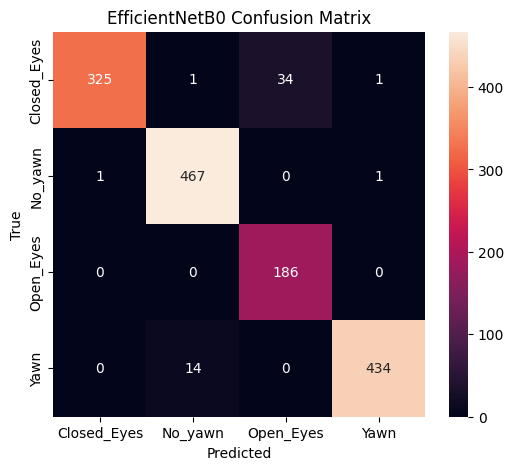

ROC-AUC: 0.9994351311694483


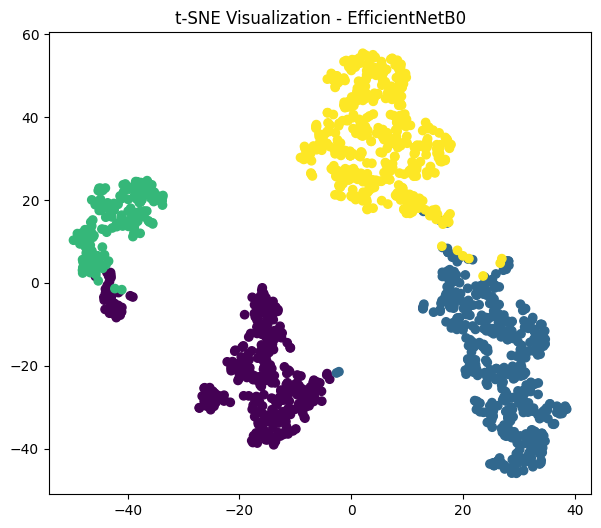

In [15]:
resnet_acc = evaluate(
    resnet,
    "ResNet18"
)

mobilenet_acc = evaluate(
    mobilenet,
    "MobileNetV2"
)

effnet_acc = evaluate(
    effnet,
    "EfficientNetB0"
)

In [16]:
accuracies = {

    "ResNet18": resnet_acc,

    "MobileNetV2": mobilenet_acc,

    "EfficientNetB0": effnet_acc
}

best_model_name = max(
    accuracies,
    key=accuracies.get
)

print("\nBest Model:", best_model_name)

print(
    "Best Accuracy:",
    accuracies[best_model_name]
)


Best Model: MobileNetV2
Best Accuracy: 0.9665300546448088


In [17]:
if best_model_name == "ResNet18":

    best_model = resnet

elif best_model_name == "MobileNetV2":

    best_model = mobilenet

else:

    best_model = effnet

In [18]:
torch.save(
    best_model.state_dict(),
    "best_model.pt"
)

print("\nBest model saved successfully!")


Best model saved successfully!


In [19]:
def test_random(model, num_images=5):

    model = model.to(device)

    model.eval()

    idx = random.sample(
        range(len(test_data)),
        num_images
    )

    for i in idx:

        img, label = test_data[i]

        inp = img.unsqueeze(0).to(device)

        out = model(inp)

        pred = torch.argmax(out).item()

        pred_label = class_names[pred]

        true_label = class_names[label]

        plt.figure(figsize=(4,4))

        plt.imshow(
            img.permute(1,2,0)
        )

        plt.title(
            f"Predicted: {pred_label}\n"
            f"True: {true_label}"
        )

        plt.axis("off")

        plt.show()

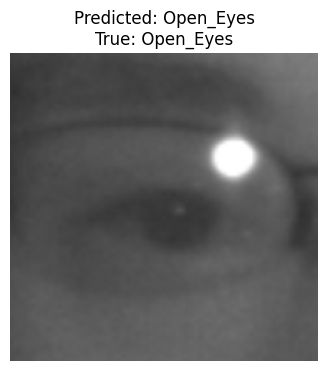

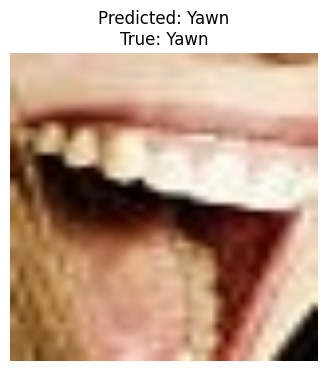

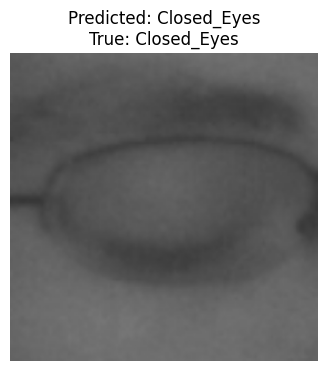

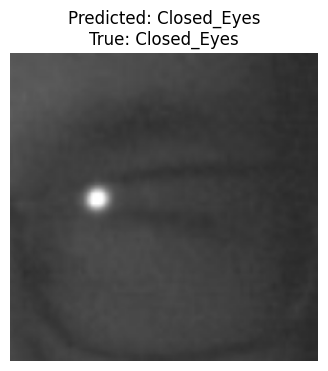

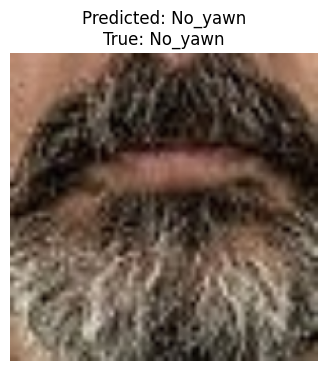

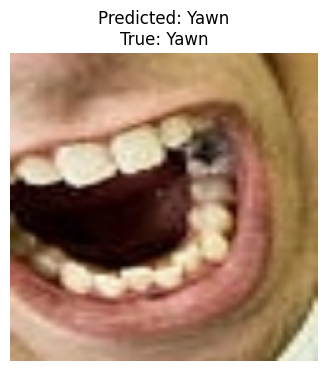

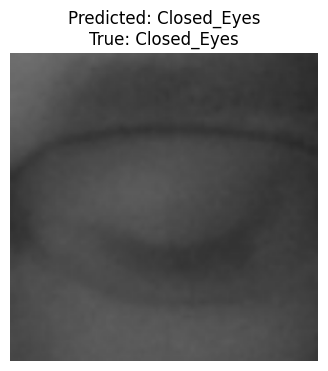

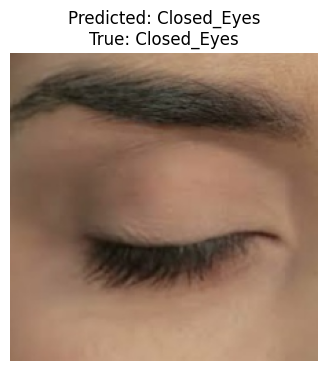

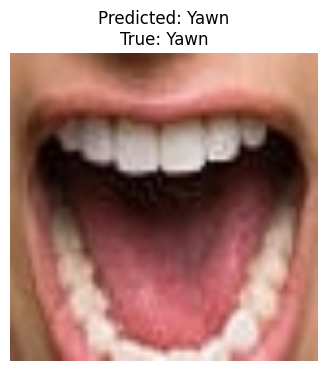

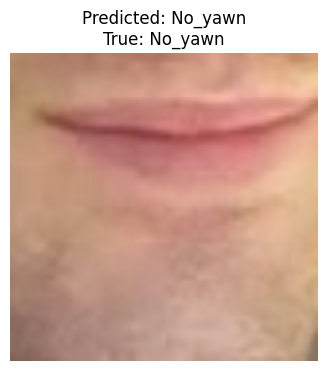

In [20]:
test_random(
    best_model,
    num_images=10
)